# Lecture 13 – Visualizations II

### DATA 2201, Fall 2025



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Lecture Outlines
- #### Kernel Density Estimate (KDE)
      - KDE Algorithm & Examples
      - Effect of bandwidth hyperparameter
- #### Plotting Distributions - Revisited
- #### Scatter Plots
- #### Hex Plots
- #### Contour Plots 

### Demo Dataset: World Bank Population

In [ ]:
wb = pd.read_csv("data/world_bank.csv", index_col=0)
wb = wb.rename(columns={'Antiretroviral therapy coverage: % of people living with HIV: 2015':"HIV rate",
                       'Gross national income per capita, Atlas method: $: 2016':'gni'})
wb.head()

## Kernel Density Estimate (KDE)

- Often, we want to identify general trends across a distribution, rather than focus on detail. 
- **Definition:** A non-parametric technique for estimating a probability density function (PDF).  
- **Purpose:** Helps identify general trends in data by providing a smooth curve for continuous distributions.  

### Idea for KDE Implementation 
Approximate the probability distribution that generated the data by:
1. Place a kernel at each data point.
2. Normalize kernels so that total area = 1.
3. Sum all kernels together.

### Toy KDE Example

In [ ]:
points = [2.2, 2.8, 3.7, 5.3, 5.7]

In [ ]:
plt.hist(points, bins=range(0, 10, 2), ec='w', density=True);

### Kernel Examples: Let's define some **kernels** and **useful functions**
- We will explain these formulas momentarily. 
- We'll also define some helper functions for visualization purposes.

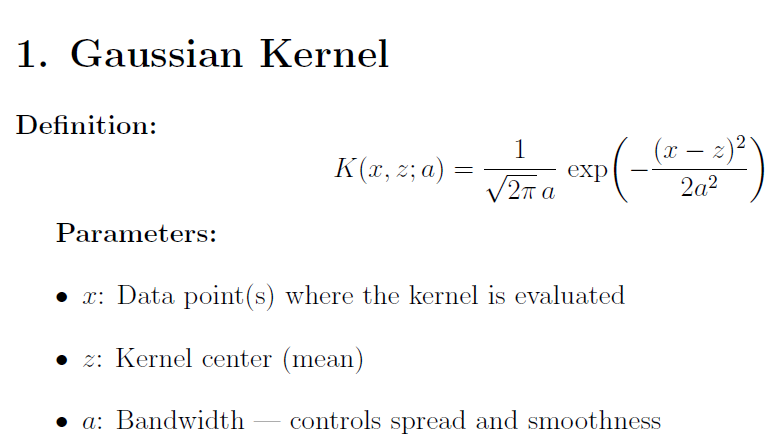

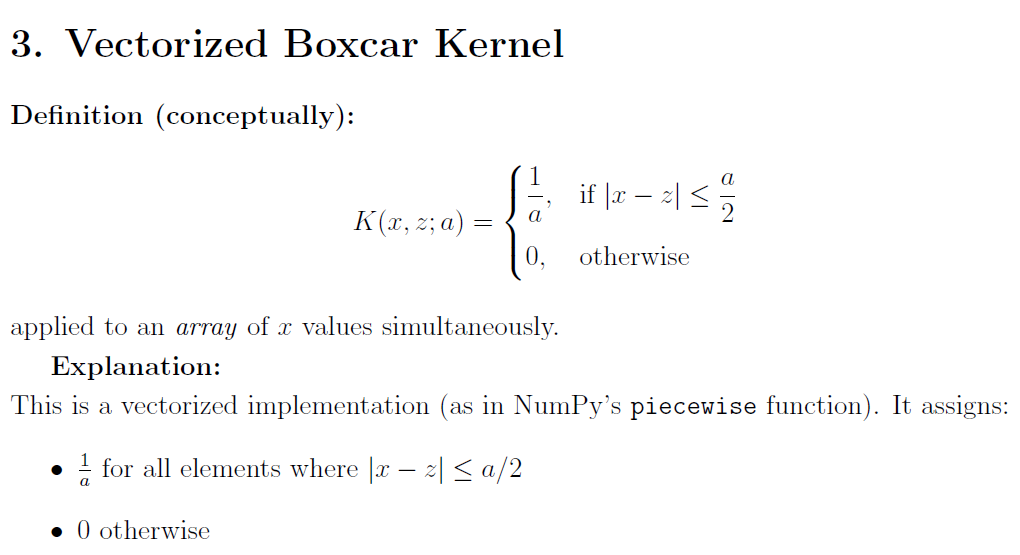

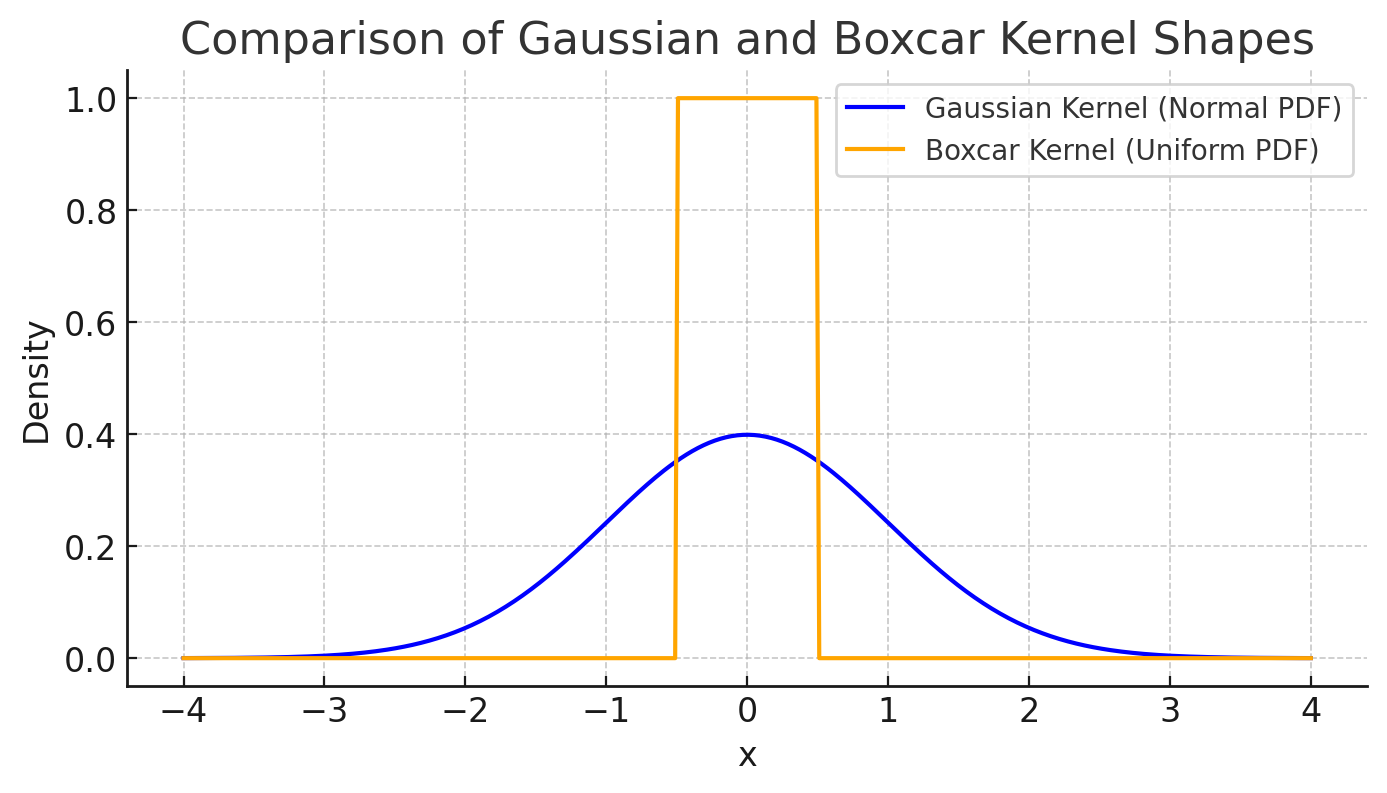

In [ ]:
def gaussian(x, z, a):
    # Gaussian kernel
    return (1/np.sqrt(2*np.pi*a**2)) * np.exp((-(x - z)**2 / (2 * a**2)))

def boxcar_basic(x, z, a):
    # Boxcar kernel
    if np.abs(x - z) <= a/2:
        return 1/a
    return 0

def boxcar(x, z, a):
    # Boxcar kernel
    cond = np.abs(x - z)
    return np.piecewise(x, [cond <= a/2, cond > a/2], [1/a, 0] )

In [ ]:
def create_kde(kernel, pts, a):
    # Takes in a kernel, set of points, and alpha
    # Returns the KDE as a function
    def f(x):
        output = 0
        for pt in pts:
            output += kernel(x, pt, a)
        return output / len(pts) # Normalization factor
    return f

def plot_kde(kernel, pts, a):
    # Calls create_kde and plots the corresponding KDE
    f = create_kde(kernel, pts, a)
    x = np.linspace(min(pts) - 5, max(pts) + 5, 1000)
    y = [f(xi) for xi in x]
    plt.plot(x, y);
    
def plot_separate_kernels(kernel, pts, a, norm=False):
    # Plots individual kernels, which are then summed to create the KDE
    x = np.linspace(min(pts) - 5, max(pts) + 5, 1000)
    for pt in pts:
        y = kernel(x, pt, a)
        if norm:
            y /= len(pts)
        plt.plot(x, y)
    
    plt.show();

#### Example: Here are our five points.

In [ ]:
plt.xlim(-3, 10)
plt.ylim(0, 0.5)
sns.rugplot(points, height=0.5);

## KDE Algorithm Steps

### Step 1: Place a kernel at each point

We'll start with the Gaussian kernel.

In [ ]:
plt.xlim(-3, 10)
plt.ylim(0, 0.5)
plot_separate_kernels(gaussian, points, a=1);

### Step 2: Normalize kernels so that total area is 1

In [ ]:
plt.xlim(-3, 10)
plt.ylim(0, 0.5)
plot_separate_kernels(gaussian, points, a=1, norm=True);

### Step 3: Sum all kernels together

In [ ]:
plt.xlim(-3, 10)
plt.ylim(0, 0.5)
plot_kde(gaussian, points, a=1)

In [ ]:
sns.kdeplot(points, bw_method=0.65)  # Magic value!
sns.histplot(points, stat='density', bins=2);

#### You can also get a very similar result in a single call by requesting the KDE be added to the histogram, with `kde=True` and some extra keywords:

In [ ]:
sns.histplot(points, bins=2, kde=True, stat='density', 
             kde_kws=dict(cut=4, bw_method=0.65));

In [ ]:
sns.kdeplot(points)
sns.histplot(points, stat='density');

In [ ]:
plt.xlim(-3, 10)
plt.ylim(0, 0.5)
plt.title(r'KDE of toy data with Gaussian kernel and $\alpha$ = 1')
plot_kde(gaussian, points, a=1)

In [ ]:
plt.xlim(-3, 10)
plt.ylim(0, 0.5)
plt.title(r'KDE of toy data with Boxcar kernel and $\alpha$ = 1')
plot_kde(boxcar, points, a=1)

## Effect of bandwidth hyperparameter $\alpha$

- **Bandwidth (h):** Controls the width of the kernels.  
- **Small bandwidth:** Produces a very wiggly curve (overfitting; too sensitive to noise).  
- **Large bandwidth:** Produces an overly smooth curve (underfitting; hides important features).  

👉 Choosing the right bandwidth is crucial for balancing detail vs. smoothness in the estimated density.  



## Example: Using World Bank Data
- Consider HIV Rate

In [ ]:
vals = wb['HIV rate'].dropna()
ax = sns.histplot(vals)
sns.rugplot(vals, color='orange', ax=ax);

In [ ]:
plt.figure(figsize=(8, 5))
plt.ylim(0, 0.25)
plt.xlim(-1, 100)
plt.title(r'KDE of tips with Gaussian kernel and $\alpha$ = 0.1')
plot_kde(gaussian, vals, a=0.1)

In [ ]:
plt.figure(figsize=(8, 5))
plt.ylim(0, 0.05)
plt.xlim(-1, 100)
plt.title(r'KDE of tips with Gaussian kernel and $\alpha$ = 1')
plot_kde(gaussian, vals, a=1)

In [ ]:
plt.figure(figsize=(8, 5))
plt.ylim(0, 0.04)
plt.xlim(-1, 100)
plt.title(r'KDE of tips with Gaussian kernel and $\alpha$ = 2')
plot_kde(gaussian, vals, a=2)

In [ ]:
plt.figure(figsize=(8, 5))
plt.ylim(0, 0.04)
plt.xlim(-1, 100)
plt.title(r'KDE of tips with Gaussian kernel and $\alpha$ = 10')
plot_kde(gaussian, vals, a=5)

## KDE Formula

$$f_{\alpha}(x) = \sum_{i = 1}^n \frac{1}{n} \cdot K_{\alpha}(x, x_i) =  \frac{1}{n} \sum_{i = 1}^n K_{\alpha}(x, x_i)$$

# Plotting Distributions - Revisited

## Diving into `displot`

Seaborn [documentation](https://seaborn.pydata.org/generated/seaborn.displot.html) for `sns.displot` lets you specify the `kind` of plot.

When plotting a histogram,  you can pass in `histplot` ([link](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot)) parameters to `displot` to specify histogram-specific features.

For example, `stat=density` normalizes the histogram such that the area under the histogram is 1.

In [ ]:
sns.displot(data=wb, 
            x="gni", 
            kind="hist", 
            stat="density") # default: stat=count and density integrates to 1
plt.title("Distribution of gross national income per capita");

What does it mean to specify `kind=kde`? We will explore this!

In [ ]:
sns.displot(data=wb, 
            x="gni", 
            kind='kde')
plt.title("Distribution of gross national income per capita");

In [ ]:
sns.displot(data=wb, 
            x="gni", 
            kind='ecdf')
plt.title("Cumulative Distribution of gross national income per capita");

## Scatter Plots

Scatter plots are used to visualize the **relationship** between two **quantitative continuous variables**.

In [ ]:
plt.scatter(wb['per capita: % growth: 2016'], 
            wb['Adult literacy rate: Female: % ages 15 and older: 2005-14'])
plt.xlabel("% growth per capita")
plt.ylabel("Female adult literacy rate");

In [ ]:
sns.scatterplot(data=wb, x='per capita: % growth: 2016', \
                y='Adult literacy rate: Female: % ages 15 and older: 2005-14', 
                hue="Continent")
plt.xlabel("% growth per capita")
plt.ylabel("Female adult literacy rate");

### Observations:
- The above plots suffer from **overplotting** – many scatter points are stacked on top of one another (particularly in the upper right region of the plot). 

**Jittering** is a processed used to address overplotting. A small amount of random noise is added to the x and y values of all datapoints. 

Decreasing the size of each scatter point using the `s` parameter of `plt.scatter` also helps.

In [ ]:
random_x_noise = np.random.uniform(-1, 1, len(wb))
random_y_noise = np.random.uniform(-5, 5, len(wb))

plt.scatter(wb['per capita: % growth: 2016']+random_x_noise, \
            wb['Adult literacy rate: Female: % ages 15 and older: 2005-14']+random_y_noise, s=15)

plt.xlabel("% growth per capita (jittered)")
plt.ylabel("Female adult literacy rate (jittered)");

In [ ]:
sns.lmplot(data=wb, x='per capita: % growth: 2016', \
           y='Adult literacy rate: Female: % ages 15 and older: 2005-14');

In [ ]:
sns.jointplot(data=wb, x='per capita: % growth: 2016', \
              y='Adult literacy rate: Female: % ages 15 and older: 2005-14');

## Hex Plots

- Rather than plot individual datapoints, plot the *density* of how datapoints are distributed in 2D.
- A darker hexagon means that more datapoints lie in that region.

In [ ]:
sns.jointplot(data=wb, x='per capita: % growth: 2016', \
              y='Adult literacy rate: Female: % ages 15 and older: 2005-14',
              kind='hex');

## Contour Plots

- Contour plots are similar to topographic maps.
- Contour lines of the same color have the same *density* of datapoints.
- The region with the darkest color contains the most datapoints of all regions.
- We can think of a contour plot as the 2D equivalent of a KDE curve.

In [ ]:
sns.kdeplot(data=wb, x='per capita: % growth: 2016', \
              y='Adult literacy rate: Female: % ages 15 and older: 2005-14', 
            fill=True);

In [ ]:
sns.jointplot(data=wb, x='per capita: % growth: 2016', \
              y='Adult literacy rate: Female: % ages 15 and older: 2005-14',
              kind='kde');

# See you next lecture!